# **Legendary Pokemon Predictor**

### *This project investigates whether a Pokémon’s battle statistics and type profile can explain what makes it Legendary. Using exploratory data analysis, feature engineering, and machine learning classification models, I evaluate which characteristics are most strongly associated with Legendary status.*

### **Import Libraries**

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from scipy.stats import ttest_ind, chi2_contingency

# Optional: suppress warnings
import warnings
warnings.filterwarnings("ignore")

# Plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


### **Load Data**

In [11]:
df = pd.read_csv(r"C:\Users\kaleb\Downloads\poke\PokemonData.csv")

### **View Data**

In [18]:
print("First 5 rows:")
print(df.head())

print("\nShape of dataset:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

First 5 rows:
   Num                   Name  Type1   Type2  HP  Attack  Defense  SpAtk  \
0    1              Bulbasaur  Grass  Poison  45      49       49     65   
1    2                Ivysaur  Grass  Poison  60      62       63     80   
2    3               Venusaur  Grass  Poison  80      82       83    100   
3    3  VenusaurMega Venusaur  Grass  Poison  80     100      123    122   
4    4             Charmander   Fire    None  39      52       43     60   

   SpDef  Speed  Generation  Legendary  
0     65     45           1          0  
1     80     60           1          0  
2    100     80           1          0  
3    120     80           1          0  
4     50     65           1          0  

Shape of dataset:
(800, 12)

Column names:
['Num', 'Name', 'Type1', 'Type2', 'HP', 'Attack', 'Defense', 'SpAtk', 'SpDef', 'Speed', 'Generation', 'Legendary']

Data types:
Num            int64
Name          object
Type1         object
Type2         object
HP             int64
Attack

### **Data Cleaning**

In [ ]:
# Standardize column names just in case
df.columns = [col.strip().replace(" ", "").replace(".", "") for col in df.columns]

# Display missing values
print("\nMissing values:")
print(df.isnull().sum())

# Fill missing Type2 values
if "Type2" in df.columns:
    df["Type2"] = df["Type2"].fillna("None")

# Convert Legendary to binary if needed
if df["Legendary"].dtype == "bool":
    df["Legendary"] = df["Legendary"].astype(int)
elif df["Legendary"].dtype == "object":
    df["Legendary"] = df["Legendary"].map({"True": 1, "False": 0, True: 1, False: 0})

# Check duplicates
print("\nDuplicate rows:", df.duplicated().sum())

# Remove duplicates if desired
df = df.drop_duplicates()

print("\nLegendary class counts:")
print(df["Legendary"].value_counts())

print("\nLegendary class proportions:")
print(df["Legendary"].value_counts(normalize=True).round(3))


Missing values:
Num             0
Name            0
Type1           0
Type2         386
HP              0
Attack          0
Defense         0
SpAtk           0
SpDef           0
Speed           0
Generation      0
Legendary       0
dtype: int64

Duplicate rows: 0

Legendary class counts:
Legendary
0    735
1     65
Name: count, dtype: int64

Legendary class proportions:
Legendary
0    0.919
1    0.081
Name: proportion, dtype: float64


### **Feature Engineering**

In [21]:
# Create engineered battle-stat features
df["StatTotal"] = df["HP"] + df["Attack"] + df["Defense"] + df["SpAtk"] + df["SpDef"] + df["Speed"]
df["OffenseScore"] = df["Attack"] + df["SpAtk"]
df["DefenseScore"] = df["HP"] + df["Defense"] + df["SpDef"]
df["AttackBias"] = df["Attack"] - df["SpAtk"]
df["DefenseBias"] = df["Defense"] - df["SpDef"]
df["SpeedOffense"] = df["Speed"] + df["Attack"] + df["SpAtk"]
df["BulkIndex"] = df["HP"] + df["Defense"] + df["SpDef"]
df["IsDualType"] = np.where(df["Type2"] != "None", 1, 0)

print("\nEngineered features added successfully.")
print(df.head())



Engineered features added successfully.
   Num                   Name  Type1   Type2  HP  Attack  Defense  SpAtk  \
0    1              Bulbasaur  Grass  Poison  45      49       49     65   
1    2                Ivysaur  Grass  Poison  60      62       63     80   
2    3               Venusaur  Grass  Poison  80      82       83    100   
3    3  VenusaurMega Venusaur  Grass  Poison  80     100      123    122   
4    4             Charmander   Fire    None  39      52       43     60   

   SpDef  Speed  Generation  Legendary  StatTotal  OffenseScore  DefenseScore  \
0     65     45           1          0        318           114           159   
1     80     60           1          0        405           142           203   
2    100     80           1          0        525           182           263   
3    120     80           1          0        625           222           323   
4     50     65           1          0        309           112           132   

   AttackBias  

### **Exploratory Data Analysis**

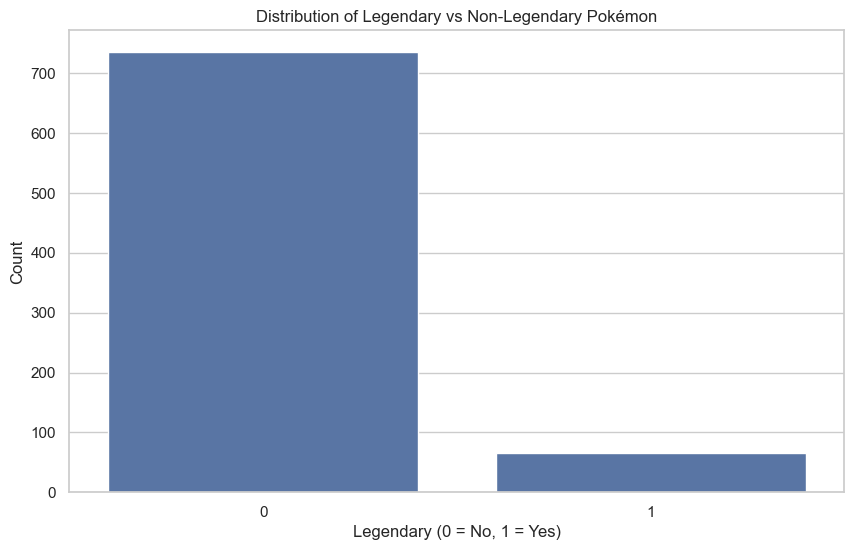

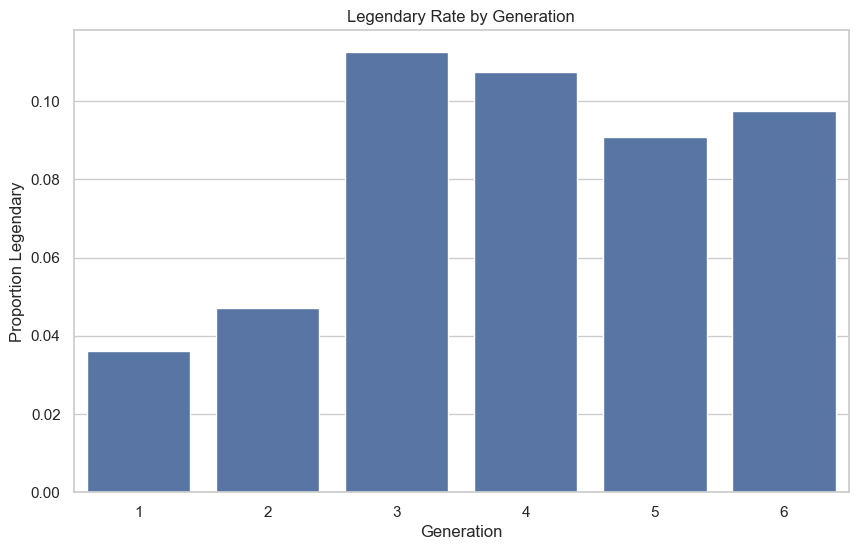

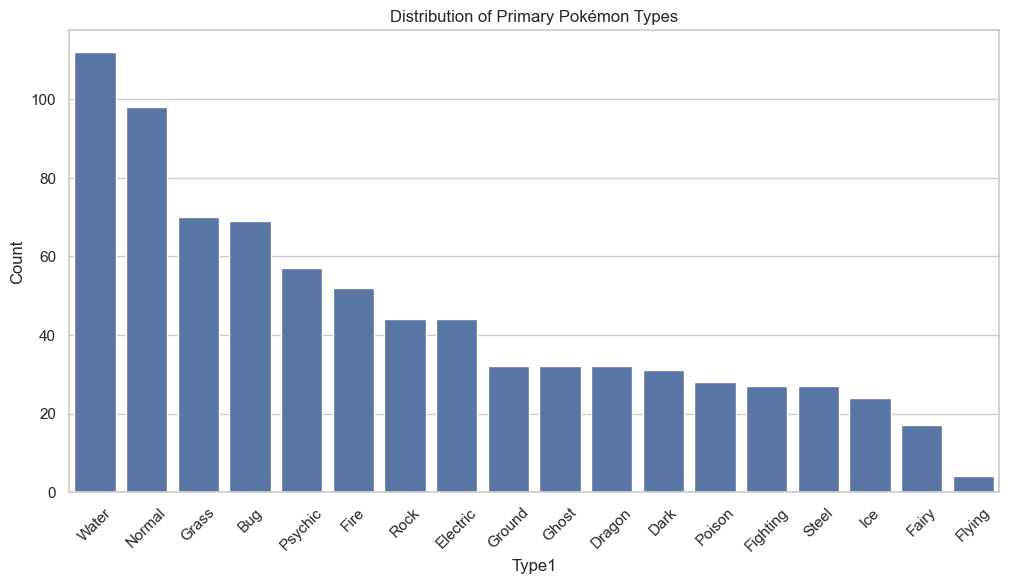

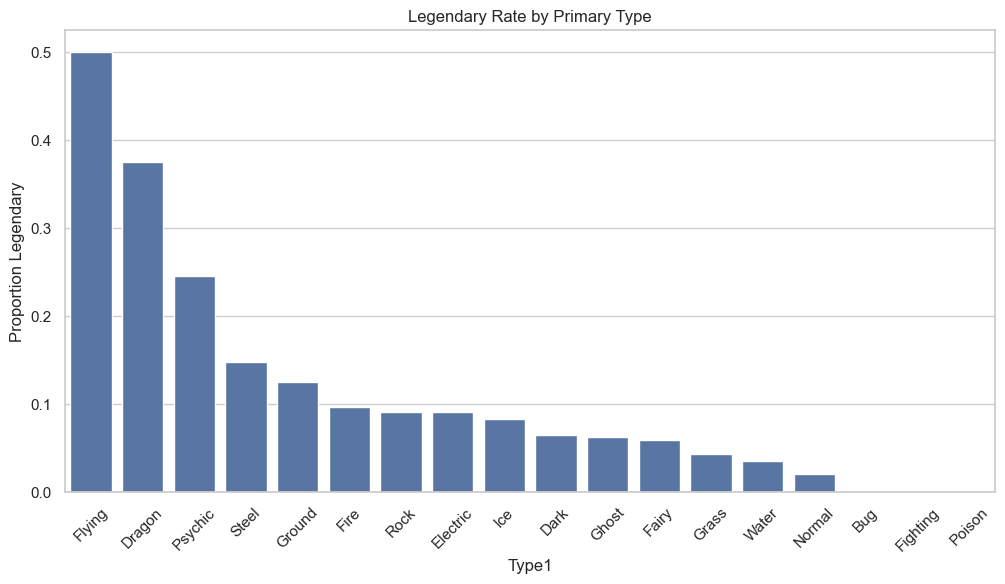

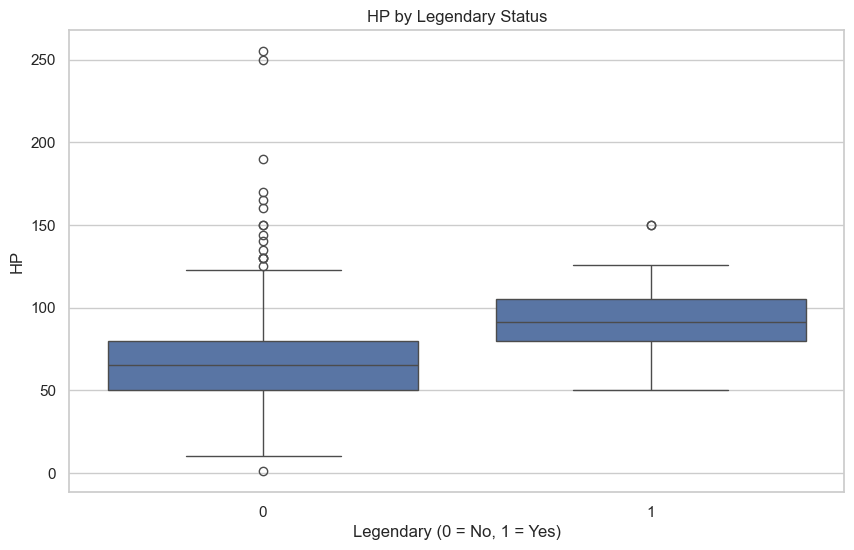

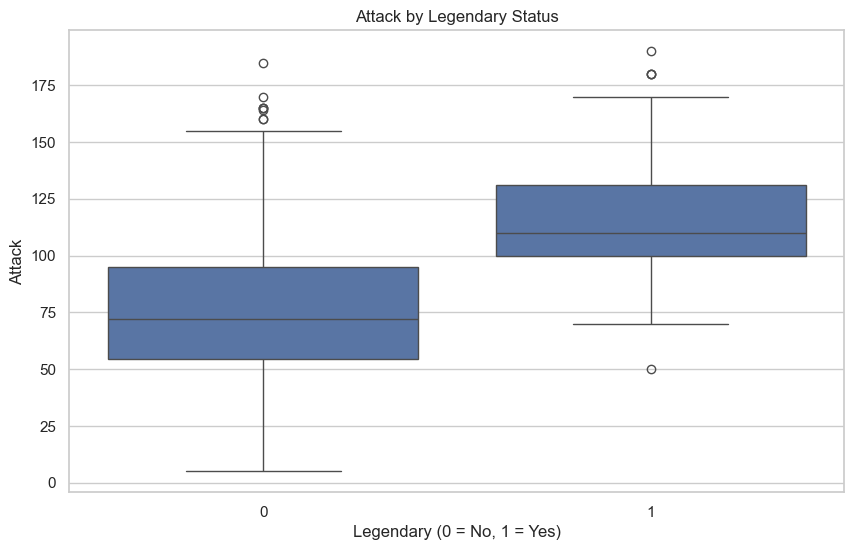

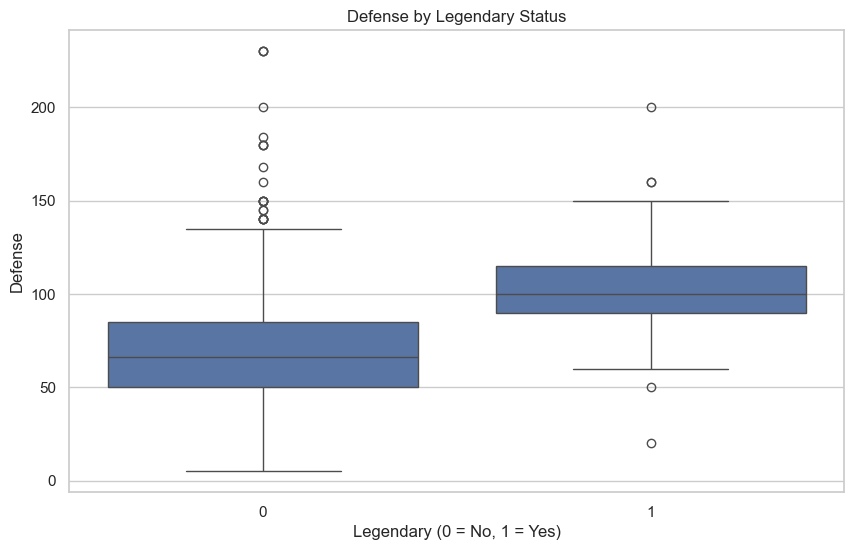

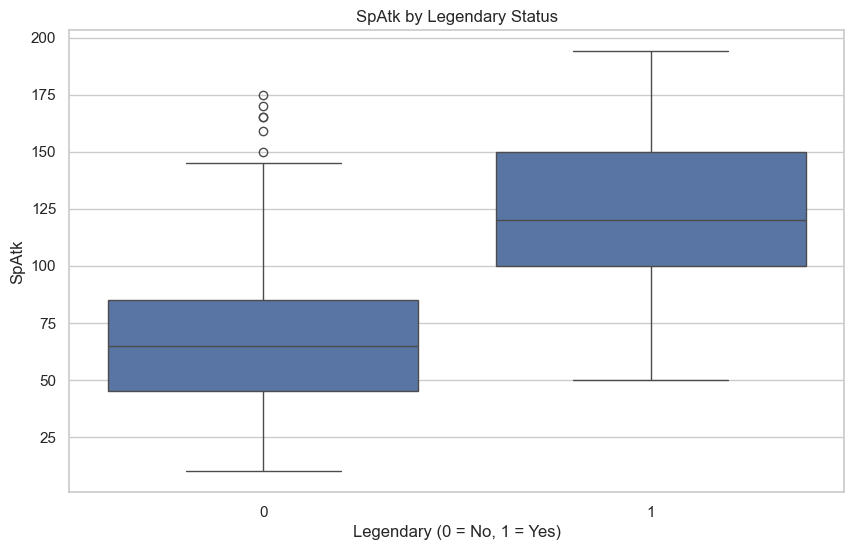

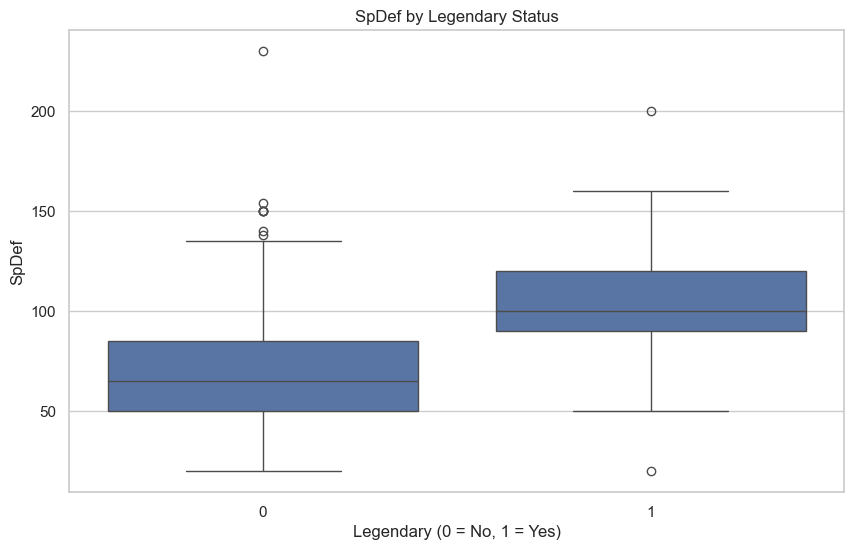

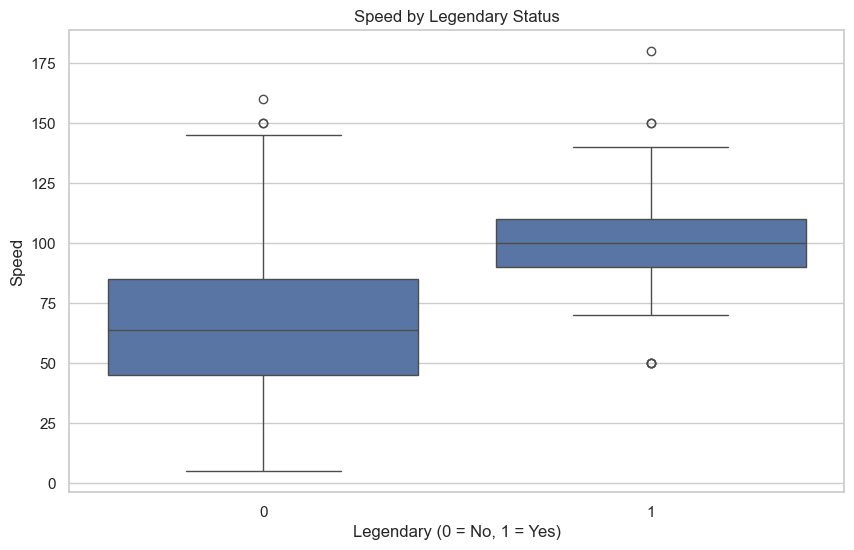

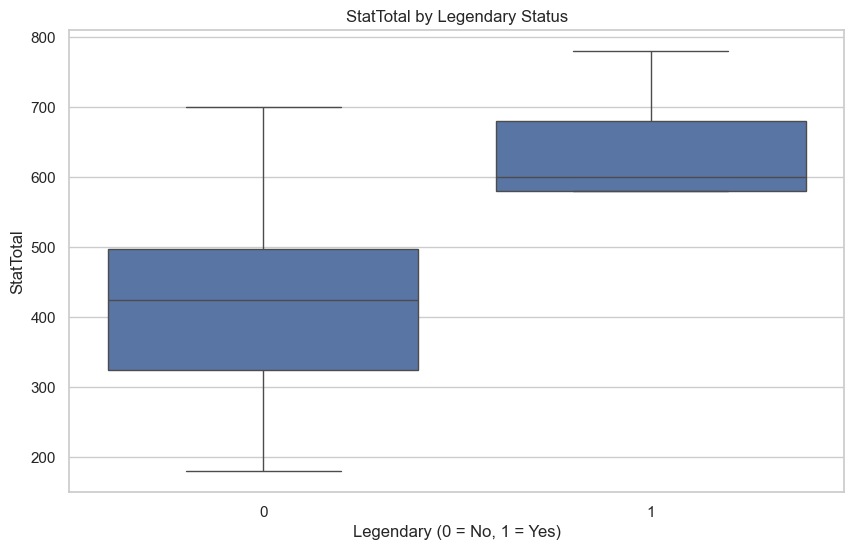

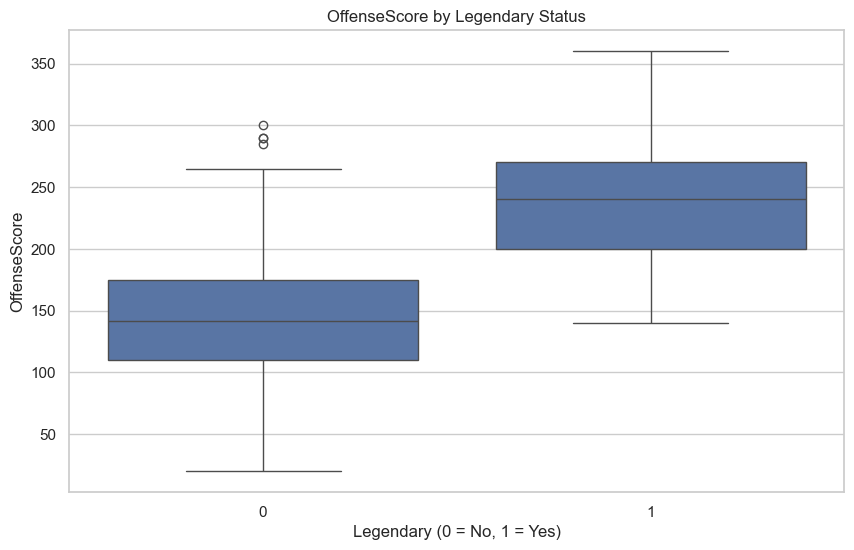

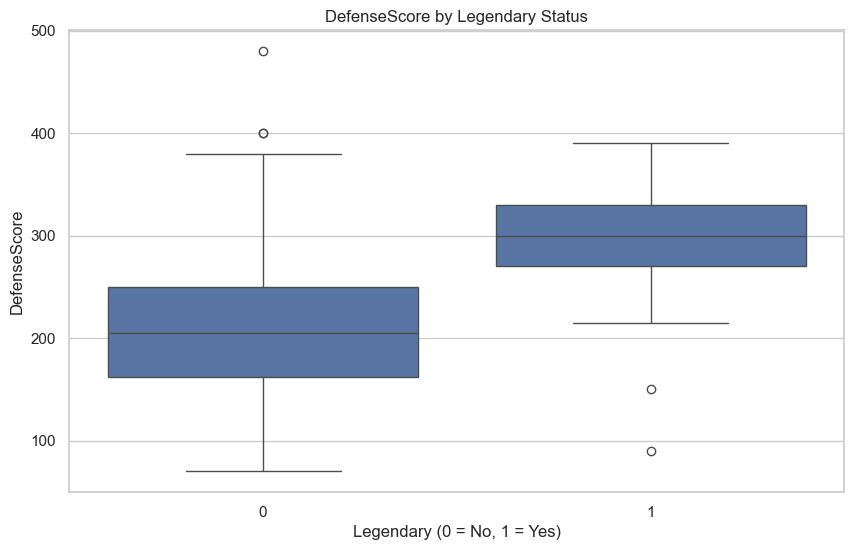

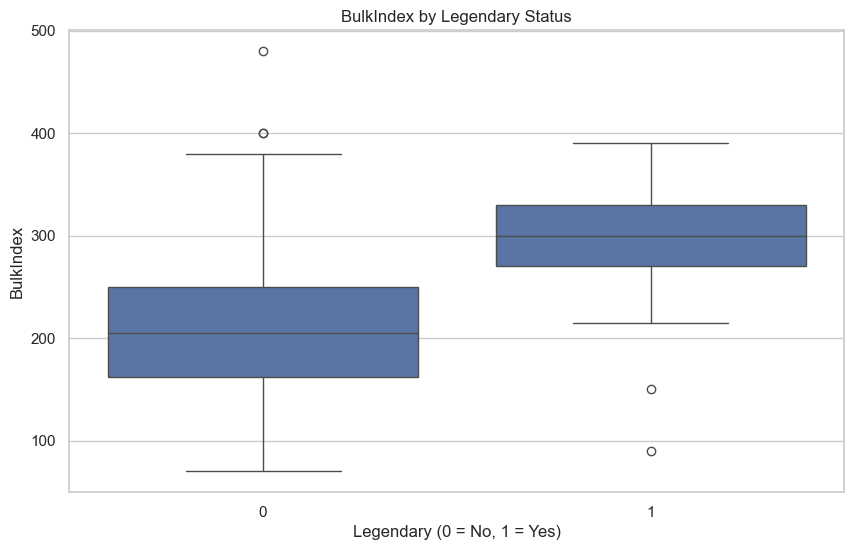

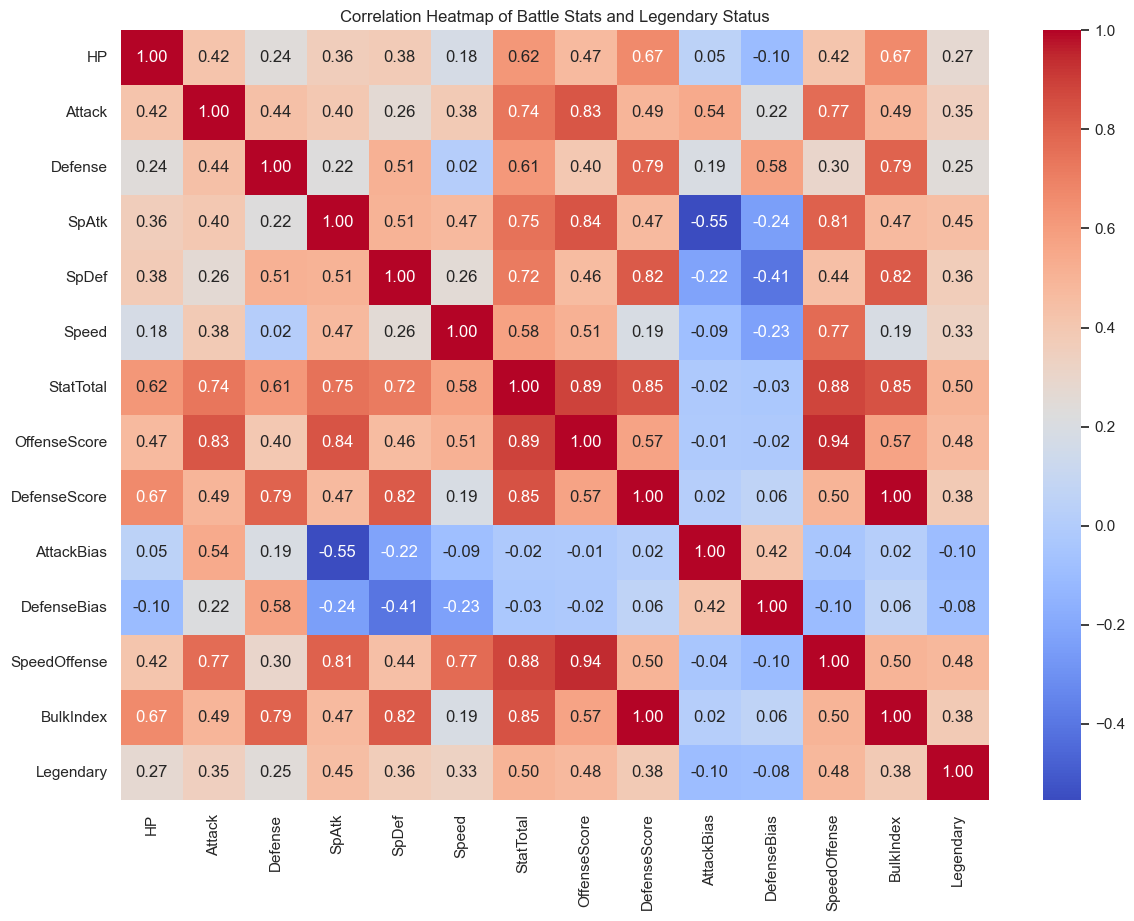

In [23]:
# --- Class distribution ---
plt.figure()
sns.countplot(data=df, x="Legendary")
plt.title("Distribution of Legendary vs Non-Legendary Pokémon")
plt.xlabel("Legendary (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

# --- Legendary rate by generation ---
legendary_by_gen = df.groupby("Generation")["Legendary"].mean().reset_index()

plt.figure()
sns.barplot(data=legendary_by_gen, x="Generation", y="Legendary")
plt.title("Legendary Rate by Generation")
plt.ylabel("Proportion Legendary")
plt.show()

# --- Type1 frequency ---
plt.figure(figsize=(12, 6))
type1_counts = df["Type1"].value_counts()
sns.barplot(x=type1_counts.index, y=type1_counts.values)
plt.title("Distribution of Primary Pokémon Types")
plt.xlabel("Type1")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# --- Legendary rate by Type1 ---
legendary_by_type = df.groupby("Type1")["Legendary"].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=legendary_by_type.index, y=legendary_by_type.values)
plt.title("Legendary Rate by Primary Type")
plt.xlabel("Type1")
plt.ylabel("Proportion Legendary")
plt.xticks(rotation=45)
plt.show()

# --- Numeric distributions by Legendary status ---
numeric_cols = [
    "HP", "Attack", "Defense", "SpAtk", "SpDef", "Speed",
    "StatTotal", "OffenseScore", "DefenseScore", "BulkIndex"
]

for col in numeric_cols:
    plt.figure()
    sns.boxplot(data=df, x="Legendary", y=col)
    plt.title(f"{col} by Legendary Status")
    plt.xlabel("Legendary (0 = No, 1 = Yes)")
    plt.show()

# --- Correlation heatmap ---
corr_cols = [
    "HP", "Attack", "Defense", "SpAtk", "SpDef", "Speed",
    "StatTotal", "OffenseScore", "DefenseScore",
    "AttackBias", "DefenseBias", "SpeedOffense", "BulkIndex", "Legendary"
]

plt.figure(figsize=(14, 10))
corr_matrix = df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Battle Stats and Legendary Status")
plt.show()

### **Statistical Testing**

In [25]:
print("\n==============================")
print("STATISTICAL TESTING")
print("==============================")

# T-tests for key stat differences
for stat in ["Speed", "SpAtk", "StatTotal", "OffenseScore", "BulkIndex"]:
    legendary_group = df[df["Legendary"] == 1][stat]
    non_legendary_group = df[df["Legendary"] == 0][stat]
    
    t_stat, p_val = ttest_ind(legendary_group, non_legendary_group, equal_var=False)
    print(f"\nT-test for {stat}:")
    print(f"t-statistic = {t_stat:.3f}, p-value = {p_val:.5f}")

# Chi-square test for Type1 vs Legendary
contingency_table = pd.crosstab(df["Type1"], df["Legendary"])
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("\nChi-Square Test: Type1 vs Legendary")
print(f"Chi-square statistic = {chi2:.3f}")
print(f"p-value = {p:.5f}")


STATISTICAL TESTING

T-test for Speed:
t-statistic = 11.475, p-value = 0.00000

T-test for SpAtk:
t-statistic = 13.417, p-value = 0.00000

T-test for StatTotal:
t-statistic = 25.834, p-value = 0.00000

T-test for OffenseScore:
t-statistic = 13.592, p-value = 0.00000

T-test for BulkIndex:
t-statistic = 13.018, p-value = 0.00000

Chi-Square Test: Type1 vs Legendary
Chi-square statistic = 90.420
p-value = 0.00000


### **Prepare for Modeling**

In [26]:
# Drop identifier / name columns from predictors
drop_cols = ["Legendary"]

if "Num" in df.columns:
    drop_cols.append("Num")
if "Name" in df.columns:
    drop_cols.append("Name")

X = df.drop(columns=drop_cols)
y = df["Legendary"]

print("\nPredictor columns:")
print(X.columns.tolist())

# Identify categorical and numeric columns
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("\nCategorical features:", categorical_features)
print("Numeric features:", numeric_features)

# Preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


Predictor columns:
['Type1', 'Type2', 'HP', 'Attack', 'Defense', 'SpAtk', 'SpDef', 'Speed', 'Generation', 'StatTotal', 'OffenseScore', 'DefenseScore', 'AttackBias', 'DefenseBias', 'SpeedOffense', 'BulkIndex', 'IsDualType']

Categorical features: ['Type1', 'Type2']
Numeric features: ['HP', 'Attack', 'Defense', 'SpAtk', 'SpDef', 'Speed', 'Generation', 'StatTotal', 'OffenseScore', 'DefenseScore', 'AttackBias', 'DefenseBias', 'SpeedOffense', 'BulkIndex', 'IsDualType']


### **Train/Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("\nTraining set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (640, 17)
Testing set shape: (160, 17)


### **Define Models**

In [28]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=500, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        class_weight="balanced"
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}


### **Train and Evaluate Models**


MODEL: Logistic Regression
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.92      0.95       147
           1       0.45      0.77      0.57        13

    accuracy                           0.91       160
   macro avg       0.72      0.84      0.76       160
weighted avg       0.94      0.91      0.92       160

Accuracy : 0.906
Precision: 0.455
Recall   : 0.769
F1 Score : 0.571
ROC AUC  : 0.956


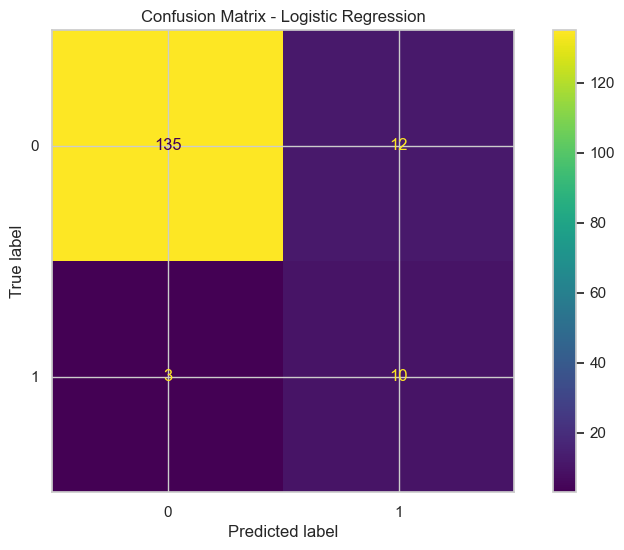

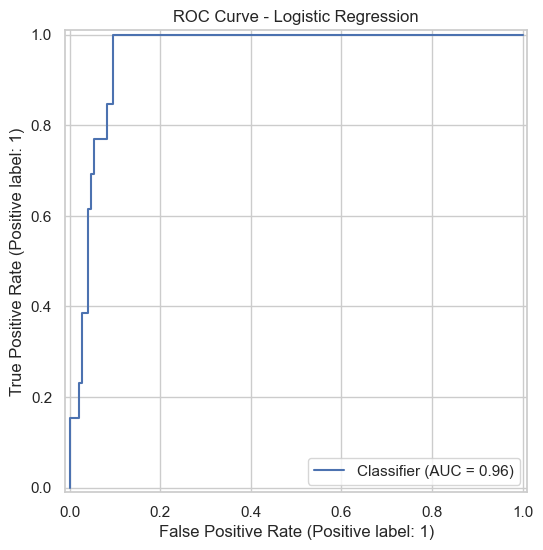


MODEL: Random Forest
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       147
           1       0.62      0.77      0.69        13

    accuracy                           0.94       160
   macro avg       0.80      0.86      0.83       160
weighted avg       0.95      0.94      0.95       160

Accuracy : 0.944
Precision: 0.625
Recall   : 0.769
F1 Score : 0.690
ROC AUC  : 0.973


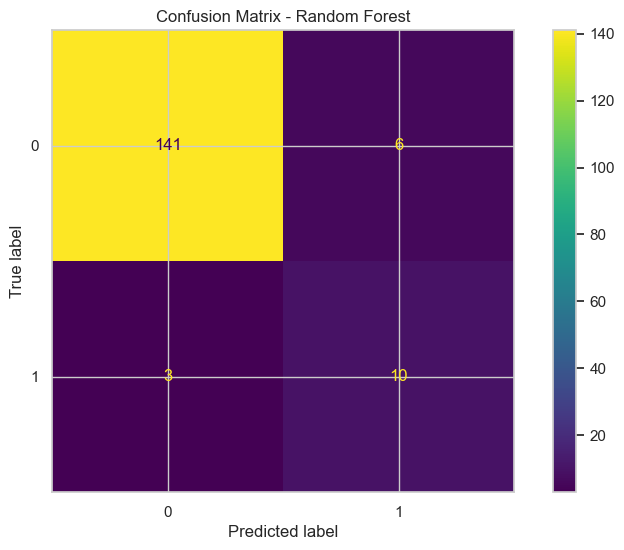

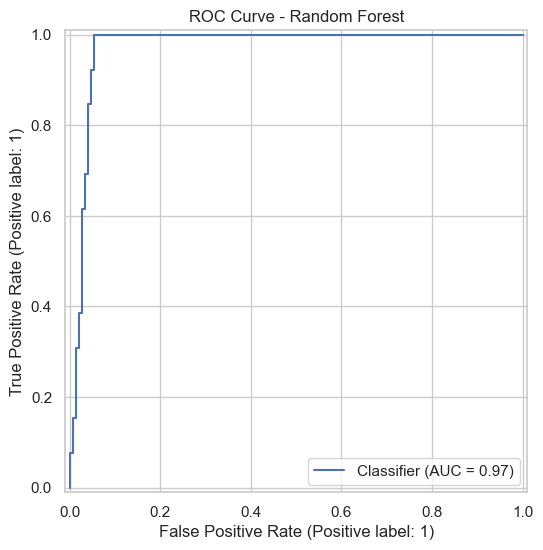


MODEL: Gradient Boosting
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       147
           1       0.71      0.92      0.80        13

    accuracy                           0.96       160
   macro avg       0.85      0.94      0.89       160
weighted avg       0.97      0.96      0.96       160

Accuracy : 0.963
Precision: 0.706
Recall   : 0.923
F1 Score : 0.800
ROC AUC  : 0.985


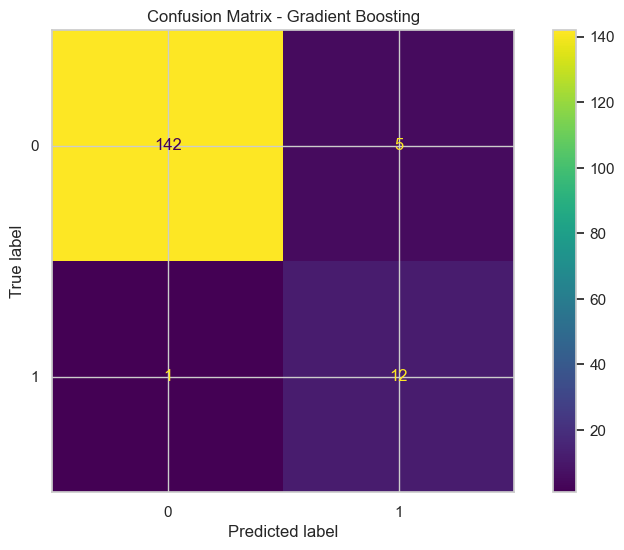

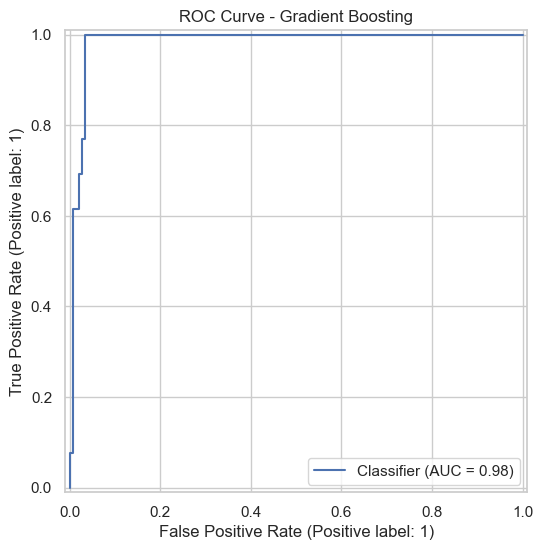

In [29]:
results = []

best_model_name = None
best_model_pipeline = None
best_auc = -np.inf

for model_name, model in models.items():
    print("\n" + "="*60)
    print(f"MODEL: {model_name}")
    print("="*60)
    
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Fit
    pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1] if hasattr(pipeline.named_steps["model"], "predict_proba") else None
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan
    
    results.append({
        "Model": model_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "ROC AUC": auc
    })
    
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    
    print(f"Accuracy : {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall   : {rec:.3f}")
    print(f"F1 Score : {f1:.3f}")
    print(f"ROC AUC  : {auc:.3f}")
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()
    
    # ROC curve
    if y_prob is not None:
        RocCurveDisplay.from_predictions(y_test, y_prob)
        plt.title(f"ROC Curve - {model_name}")
        plt.show()
    
    # Track best model
    if auc > best_auc:
        best_auc = auc
        best_model_name = model_name
        best_model_pipeline = pipeline


### **Model Comparison Table**


MODEL COMPARISON
                 Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
2    Gradient Boosting   0.96250   0.705882  0.923077  0.800000  0.984825
1        Random Forest   0.94375   0.625000  0.769231  0.689655  0.972789
0  Logistic Regression   0.90625   0.454545  0.769231  0.571429  0.956044


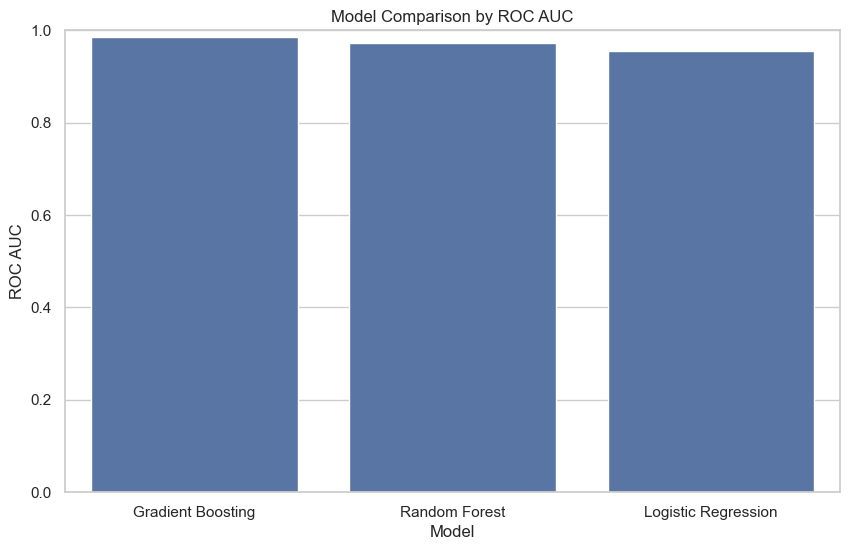

In [30]:
results_df = pd.DataFrame(results).sort_values(by="ROC AUC", ascending=False)

print("\n==============================")
print("MODEL COMPARISON")
print("==============================")
print(results_df)

# Visualize model comparison
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x="Model", y="ROC AUC")
plt.title("Model Comparison by ROC AUC")
plt.ylim(0, 1)
plt.show()

### **Cross-Validation**

In [31]:
print("\n==============================")
print("CROSS-VALIDATION ON BEST MODEL")
print("==============================")
print(f"Best model: {best_model_name}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model_pipeline, X, y, cv=cv, scoring="roc_auc")

print("Cross-Validated ROC AUC Scores:", np.round(cv_scores, 3))
print("Mean ROC AUC:", round(cv_scores.mean(), 3))
print("Std Dev ROC AUC:", round(cv_scores.std(), 3))



CROSS-VALIDATION ON BEST MODEL
Best model: Gradient Boosting
Cross-Validated ROC AUC Scores: [0.991 0.984 0.985 0.998 0.99 ]
Mean ROC AUC: 0.99
Std Dev ROC AUC: 0.005


### **Feature Importance**


MODEL INTERPRETATION

Top 15 Most Important Features:
          Feature  Importance
7       StatTotal    0.697923
10     AttackBias    0.108397
11    DefenseBias    0.045144
25   Type1_Ground    0.019811
1          Attack    0.018701
0              HP    0.017336
12   SpeedOffense    0.013928
6      Generation    0.012589
42    Type2_Grass    0.009477
3           SpAtk    0.007224
26      Type1_Ice    0.005678
4           SpDef    0.005459
43   Type2_Ground    0.004802
29  Type1_Psychic    0.004507
5           Speed    0.003552


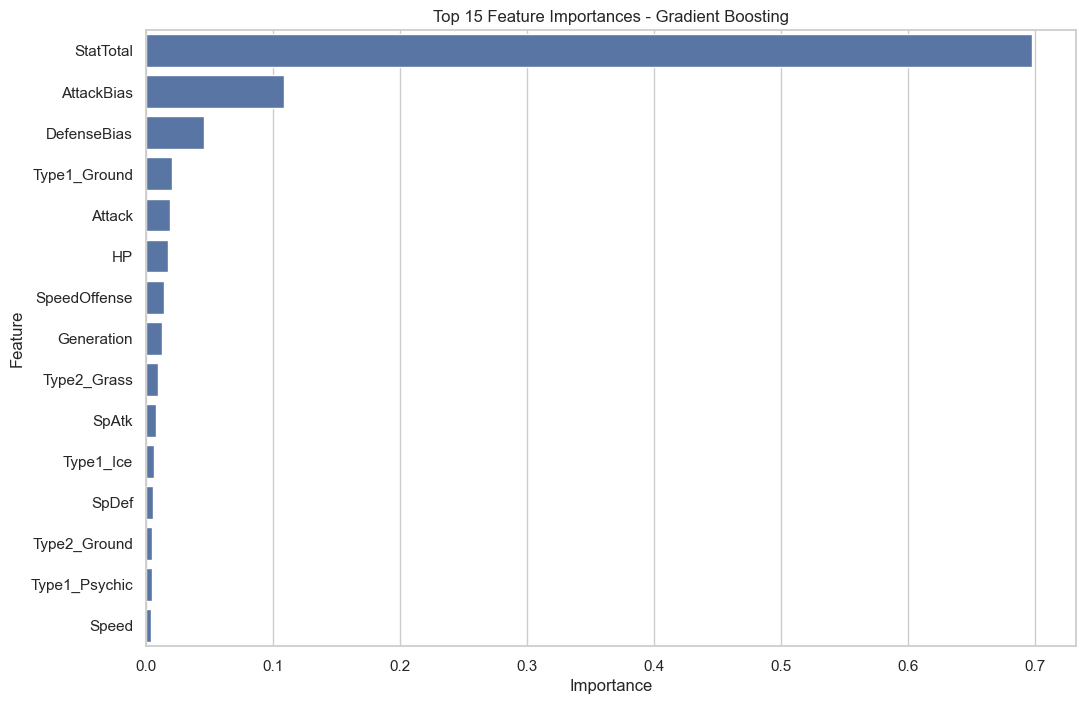

In [32]:
print("\n==============================")
print("MODEL INTERPRETATION")
print("==============================")

# Extract feature names after preprocessing
feature_names_num = numeric_features

# Get one-hot encoded categorical feature names
ohe = best_model_pipeline.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
feature_names_cat = ohe.get_feature_names_out(categorical_features)

all_feature_names = np.concatenate([feature_names_num, feature_names_cat])

# Random Forest feature importance
if best_model_name == "Random Forest":
    importances = best_model_pipeline.named_steps["model"].feature_importances_
    
    feat_imp_df = pd.DataFrame({
        "Feature": all_feature_names,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False)
    
    print("\nTop 15 Most Important Features:")
    print(feat_imp_df.head(15))
    
    plt.figure(figsize=(12, 8))
    sns.barplot(data=feat_imp_df.head(15), x="Importance", y="Feature")
    plt.title("Top 15 Feature Importances - Random Forest")
    plt.show()

# Logistic Regression coefficients
elif best_model_name == "Logistic Regression":
    coefs = best_model_pipeline.named_steps["model"].coef_[0]
    
    coef_df = pd.DataFrame({
        "Feature": all_feature_names,
        "Coefficient": coefs
    }).sort_values(by="Coefficient", ascending=False)
    
    print("\nTop 10 Positive Predictors of Legendary Status:")
    print(coef_df.head(10))
    
    print("\nTop 10 Negative Predictors of Legendary Status:")
    print(coef_df.tail(10))
    
    plt.figure(figsize=(12, 8))
    top_coef_df = pd.concat([coef_df.head(10), coef_df.tail(10)])
    sns.barplot(data=top_coef_df, x="Coefficient", y="Feature")
    plt.title("Top Logistic Regression Coefficients")
    plt.show()

# Gradient Boosting feature importance
elif best_model_name == "Gradient Boosting":
    importances = best_model_pipeline.named_steps["model"].feature_importances_
    
    feat_imp_df = pd.DataFrame({
        "Feature": all_feature_names,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False)
    
    print("\nTop 15 Most Important Features:")
    print(feat_imp_df.head(15))
    
    plt.figure(figsize=(12, 8))
    sns.barplot(data=feat_imp_df.head(15), x="Importance", y="Feature")
    plt.title("Top 15 Feature Importances - Gradient Boosting")
    plt.show()


### **Sample Predictions**

In [33]:
print("\n==============================")
print("SAMPLE PREDICTIONS")
print("==============================")

sample_preds = X_test.copy()
sample_preds["ActualLegendary"] = y_test.values
sample_preds["PredictedLegendary"] = best_model_pipeline.predict(X_test)

if hasattr(best_model_pipeline.named_steps["model"], "predict_proba"):
    sample_preds["LegendaryProbability"] = best_model_pipeline.predict_proba(X_test)[:, 1]

# Add name back if possible
if "Name" in df.columns:
    sample_preds = sample_preds.merge(df[["Name"]], left_index=True, right_index=True, how="left")

print(sample_preds.head(10))


SAMPLE PREDICTIONS
        Type1    Type2   HP  Attack  Defense  SpAtk  SpDef  Speed  Generation  \
249     Water   Dragon   75      95       95     95     95     85           2   
128     Water     None   80      92       65     65     80     68           1   
563    Normal     None   45      55       39     35     39     42           5   
341  Electric     None   60      40       50     75     85     95           3   
785     Ghost    Grass   55      85      122     58     75     99           6   
608     Grass     None   45      35       50     70     50     30           5   
689    Normal   Flying  100     123       75     57     75     80           5   
165   Psychic     None  100     100      100    100    100    100           1   
747   Psychic     None   74      48       76     83     81    104           6   
130     Water  Psychic   60      75       85    100     85    115           1   

     StatTotal  ...  DefenseScore  AttackBias  DefenseBias  SpeedOffense  \
249        5

### **Final Summary**

In [34]:
print("\n==============================")
print("FINAL SUMMARY")
print("==============================")
print(f"Best model: {best_model_name}")
print(f"Best ROC AUC: {best_auc:.3f}")

print("\nTop-level takeaway:")
print("This project examined whether Pokémon battle stats and type profiles can predict Legendary status.")
print("The results suggest that Legendary Pokémon are distinguishable through a combination of total power,")
print("offensive capability, speed, and type-related characteristics.")


FINAL SUMMARY
Best model: Gradient Boosting
Best ROC AUC: 0.985

Top-level takeaway:
This project examined whether Pokémon battle stats and type profiles can predict Legendary status.
The results suggest that Legendary Pokémon are distinguishable through a combination of total power,
offensive capability, speed, and type-related characteristics.
